In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import tensorflow as tf

from plotly.subplots import make_subplots
from sklearn.compose import ColumnTransformer
from sklearn.datasets import load_diabetes, load_iris, load_wine
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    auc,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_curve,
    roc_auc_score,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder
)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.datasets import mnist
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

2026-05-31 17:57:29.594794: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-31 17:57:29.817864: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-31 17:57:30.030666: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780243050.174657   32944 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780243050.216639   32944 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780243050.566903   32944 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loader_simple import load_and_preprocess

df = load_and_preprocess(PROJECT_ROOT / "data" / "raw" / "dataset_practica_final.csv")
X = df.drop(columns="is_canceled")
y = df["is_canceled"]

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train = X_train.copy()
X_test = X_test.copy()

LOG_COLUMNS = [
    "lead_time",
    "days_in_waiting_list",
    "previous_cancellations",
    "previous_bookings_not_canceled",
]

log_columns = [c for c in LOG_COLUMNS if c in X_train.columns]
X_train[log_columns] = np.log1p(X_train[log_columns])
X_test[log_columns]  = np.log1p(X_test[log_columns])

CONTINUOUS_COLUMNS = [
    "lead_time",
    "arrival_date_week_number",
    "arrival_date_day_of_month",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "booking_changes",
    "days_in_waiting_list",
    "adr",
    "adr_per_person",
    "adr_per_night",
    "required_car_parking_spaces",
    "total_of_special_requests",
    "total_guests",
    "total_nights",
]

scaled_columns = [column for column in CONTINUOUS_COLUMNS if column in X_train.columns]
scaler = StandardScaler()
X_train[scaled_columns] = scaler.fit_transform(X_train[scaled_columns])
X_test[scaled_columns] = scaler.transform(X_test[scaled_columns])

X_train = X_train.astype("float32")
X_test  = X_test.astype("float32")
X_train.shape, X_test.shape

((94850, 48), (23713, 48))

In [4]:
import keras 
modelo = models.Sequential(layers=[
    layers.Input(shape=(X_train.shape[1],), name='i1'),    
    layers.Dense(64, activation='relu', name='h1'),
    layers.Dense(32, activation='relu', name='h2'),
    layers.Dense(1, activation='sigmoid', name='o1')
])

# Compilamos el modelo
optimizer_adam = tf.keras.optimizers.Adam(learning_rate=0.001)
modelo.compile(optimizer=optimizer_adam, loss='binary_crossentropy',  metrics=["accuracy", keras.metrics.AUC(name="auc")])

2026-05-31 17:59:43.565983: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [5]:
modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ h1 (Dense)                      │ (None, 64)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ h2 (Dense)                      │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ o1 (Dense)                      │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,249 (20.50 KB)

 Trainable params: 5,249 (20.50 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history  = modelo.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.2, verbose=1)

Epoch 1/50
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 0s -362us/step - accuracy: 0.7717 - auc: 0.8216 - loss: 0.4671 - val_accuracy: 0.8218 - val_auc: 0.8828 - val_loss: 0.3879
Epoch 2/50
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8190 - auc: 0.8833 - loss: 0.3871 - val_accuracy: 0.8249 - val_auc: 0.8880 - val_loss: 0.3812
Epoch 3/50
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8236 - auc: 0.8906 - loss: 0.3772 - val_accuracy: 0.8199 - val_auc: 0.8897 - val_loss: 0.3845
Epoch 4/50
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8270 - auc: 0.8958 - loss: 0.3711 - val_accuracy: 0.8296 - val_auc: 0.8933 - val_loss: 0.3719
Epoch 5/50
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8297 - auc: 0.8981 - loss: 0.3671 - val_accuracy: 0.8292 - val_auc: 0.8960 - val_loss: 0.3697
Epoch 6/50
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8291 - auc: 0.8977 - loss: 0.3661 - val_accuracy: 0.8294 - val_auc: 0.8951 - val_loss: 0.3697
Epoch 7/50
1186/1186 ━━━━

In [8]:
# Evaluamos el modelo en el conjunto de prueba
loss, accuracy, auc_metric = modelo.evaluate(X_test, y_test, verbose=1)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}, Test AUC: {auc_metric:.4f}")

742/742 ━━━━━━━━━━━━━━━━━━━━ 1s 873us/step - accuracy: 0.8349 - auc: 0.9030 - loss: 0.3678
Test Loss: 0.3733, Test Accuracy: 0.8295, Test AUC: 0.9001


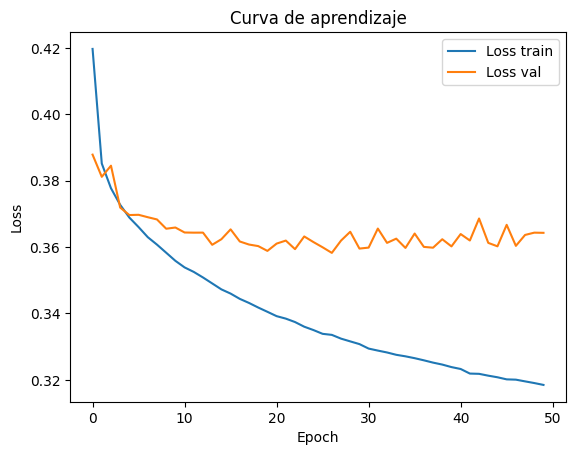

In [9]:
# Se muestra la función de coste del modelo

plt.plot(history.history['loss'], label='Loss train')
plt.plot(history.history['val_loss'], label='Loss val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Curva de aprendizaje')
plt.legend()
plt.show()

742/742 ━━━━━━━━━━━━━━━━━━━━ 0s 509us/step


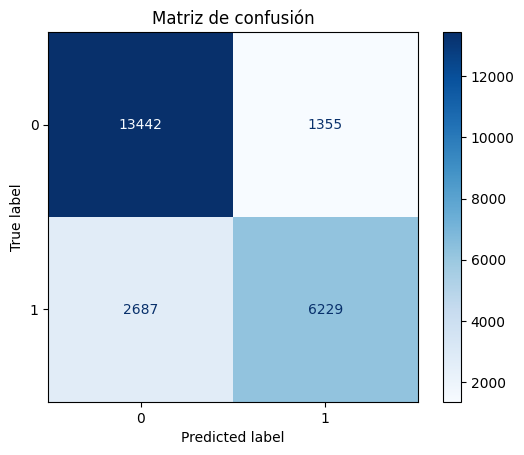

In [10]:
y_pred_prob = modelo.predict(X_test)
y_pred = (y_pred_prob >= 0.5).astype(int).flatten()

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Matriz de confusión')
plt.show()

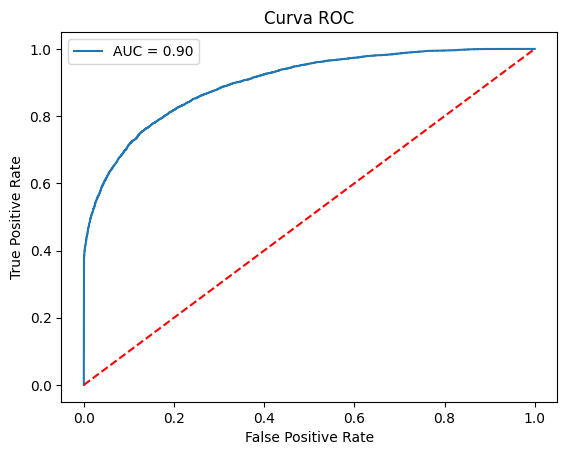

In [11]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label='AUC = {:.2f}'.format(roc_auc))
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend()
plt.show()

In [19]:
import keras 
modelo_reg = models.Sequential(layers=[
    layers.Input(shape=(X_train.shape[1],), name='i1'),    
    layers.Dense(64, activation='relu', name='h1'),
    layers.Dropout(0.5),
    layers.Dense(32, activation='relu', name='h2'),
    layers.Dense(1, activation='sigmoid', name='o1')
])

# Compilamos el modelo
optimizer_adam = tf.keras.optimizers.Adam(learning_rate=0.001)
modelo_reg.compile(optimizer=optimizer_adam, loss='binary_crossentropy',  metrics=["accuracy", keras.metrics.AUC(name="auc")])

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

In [20]:
modelo_reg.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ h1 (Dense)                      │ (None, 64)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ h2 (Dense)                      │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ o1 (Dense)                      │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,249 (20.50 KB)

 Trainable params: 5,249 (20.50 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
history_early = modelo_reg.fit(X_train, y_train, epochs=100, validation_split=0.2, batch_size=64, verbose=1, callbacks=[early_stopping])

Epoch 1/100
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7508 - auc: 0.7864 - loss: 0.5129 - val_accuracy: 0.8179 - val_auc: 0.8743 - val_loss: 0.3996
Epoch 2/100
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8102 - auc: 0.8641 - loss: 0.4137 - val_accuracy: 0.8210 - val_auc: 0.8820 - val_loss: 0.3933
Epoch 3/100
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8119 - auc: 0.8739 - loss: 0.4029 - val_accuracy: 0.8227 - val_auc: 0.8858 - val_loss: 0.3885
Epoch 4/100
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8155 - auc: 0.8776 - loss: 0.3965 - val_accuracy: 0.8224 - val_auc: 0.8874 - val_loss: 0.3845
Epoch 5/100
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8153 - auc: 0.8786 - loss: 0.3945 - val_accuracy: 0.8224 - val_auc: 0.8900 - val_loss: 0.3788
Epoch 6/100
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8174 - auc: 0.8825 - loss: 0.3910 - val_accuracy: 0.8226 - val_auc: 0.8911 - val_loss: 0.3781
Epoch 7/100
1186/1186 

In [22]:
loss, accuracy, auc_metric = modelo_reg.evaluate(X_test, y_test, verbose=1)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}, Test AUC: {auc_metric:.4f}")

742/742 ━━━━━━━━━━━━━━━━━━━━ 1s 870us/step - accuracy: 0.8293 - auc: 0.8967 - loss: 0.3717
Test Loss: 0.3730, Test Accuracy: 0.8260, Test AUC: 0.8961


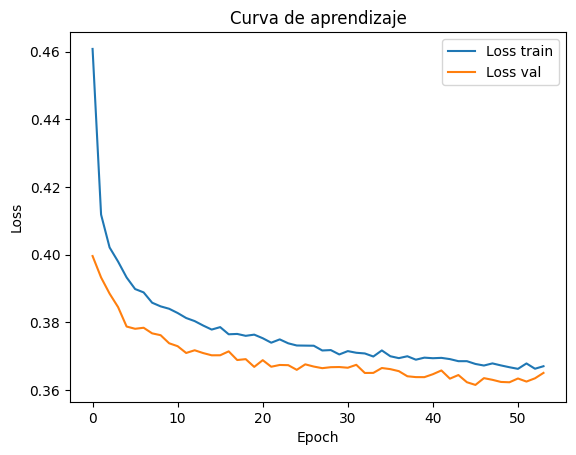

In [23]:
# Se muestra la función de coste del modelo

plt.plot(history_early.history['loss'], label='Loss train')
plt.plot(history_early.history['val_loss'], label='Loss val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Curva de aprendizaje')
plt.legend()
plt.show()